In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.lines as mlines

In [ ]:

# "indir" is a custom input path, and "outdir" is a custom output path.
# indir=""
# outdir=""

In [ ]:
meta_data = pd.read_csv(f"{indir}/22-metaData_group_Cor.csv")

In [3]:
meta_data

,group,gene_id,Correlation_5mC,Correlation_5hmC,Correlation_mC_hmC
0,[5mCG -],ENSMUSG00000000563.17,-0.013062,0.012414,-0.002159
1,[5mCG -],ENSMUSG00000001521.12,-0.017107,0.010668,-0.007267
2,[5mCG -],ENSMUSG00000001774.8,-0.018618,0.009601,-0.011793
3,[5mCG -],ENSMUSG00000002428.12,-0.012320,0.002102,-0.010752
4,[5mCG -],ENSMUSG00000002718.14,-0.011716,0.005524,-0.009005
...,...,...,...,...,...
3691,[5hmCG +]:[(5mCG+5hmCG) +],ENSMUSG00000113387.1,-0.006658,0.028145,0.028134
3692,[5mCG -]:[5hmCG +],ENSMUSG00000113642.1,-0.011888,0.023326,0.004331
3693,[5mCG -]:[5hmCG +],ENSMUSG00000116673.1,-0.026441,0.027127,-0.009056
3694,[5mCG -]:[5hmCG +],ENSMUSG00000116858.1,-0.017230,0.017334,-0.002567


In [54]:
filtered_meta_data = meta_data[
    (meta_data['Correlation_5mC'] < 0.05) |
    (meta_data['Correlation_5hmC'] < 0.05) |
    (meta_data['Correlation_mC_hmC'] < 0.05)
]

In [55]:
filtered_meta_data

,group,gene_id,Correlation_5mC,Correlation_5hmC,Correlation_mC_hmC
0,[5mCG -],ENSMUSG00000000563.17,-0.013062,0.012414,-0.002159
1,[5mCG -],ENSMUSG00000001521.12,-0.017107,0.010668,-0.007267
2,[5mCG -],ENSMUSG00000001774.8,-0.018618,0.009601,-0.011793
3,[5mCG -],ENSMUSG00000002428.12,-0.012320,0.002102,-0.010752
4,[5mCG -],ENSMUSG00000002718.14,-0.011716,0.005524,-0.009005
...,...,...,...,...,...
3691,[5hmCG +]:[(5mCG+5hmCG) +],ENSMUSG00000113387.1,-0.006658,0.028145,0.028134
3692,[5mCG -]:[5hmCG +],ENSMUSG00000113642.1,-0.011888,0.023326,0.004331
3693,[5mCG -]:[5hmCG +],ENSMUSG00000116673.1,-0.026441,0.027127,-0.009056
3694,[5mCG -]:[5hmCG +],ENSMUSG00000116858.1,-0.017230,0.017334,-0.002567


In [56]:
filtered_meta_data = meta_data[
    ~(
        ((meta_data['Correlation_5mC'] > 0) & (meta_data['Correlation_5mC'] < 0.05)) |
        ((meta_data['Correlation_5hmC'] > 0) & (meta_data['Correlation_5hmC'] < 0.05)) |
        ((meta_data['Correlation_mC_hmC'] > 0) & (meta_data['Correlation_mC_hmC'] < 0.05))
    )
]

In [57]:
filtered_meta_data

,group,gene_id,Correlation_5mC,Correlation_5hmC,Correlation_mC_hmC
6,[5mCG -],ENSMUSG00000003410.8,-0.011422,-0.000346,-0.011299
13,[5mCG -],ENSMUSG00000008730.17,-0.012657,-0.000873,-0.009213
42,[5mCG -],ENSMUSG00000020719.14,-0.014741,-0.004300,-0.010900
52,[(5mCG+5hmCG) -],ENSMUSG00000021939.8,-0.009735,-0.006698,-0.017965
54,[(5mCG+5hmCG) -],ENSMUSG00000021986.8,-0.008405,-0.010178,-0.014810
...,...,...,...,...,...
3682,[5mCG -]:[5hmCG +],ENSMUSG00000109394.2,-0.055602,0.063305,-0.004145
3683,[5mCG -]:[(5mCG+5hmCG) -],ENSMUSG00000110523.1,-0.073629,-0.002637,-0.080194
3684,[5mCG -]:[(5mCG+5hmCG) -],ENSMUSG00000110723.1,-0.017115,-0.002788,-0.018650
3687,[5mCG -]:[(5mCG+5hmCG) -],ENSMUSG00000111910.1,-0.023441,-0.001271,-0.028162


In [4]:
meta_data = meta_data[
    ~(
        ((meta_data['Correlation_5mC'] > 0) & (meta_data['Correlation_5mC'] < 0.05)) |
        ((meta_data['Correlation_5hmC'] > 0) & (meta_data['Correlation_5hmC'] < 0.05)) |
        ((meta_data['Correlation_mC_hmC'] > 0) & (meta_data['Correlation_mC_hmC'] < 0.05))
    )
]

In [5]:
meta_data

,group,gene_id,Correlation_5mC,Correlation_5hmC,Correlation_mC_hmC
6,[5mCG -],ENSMUSG00000003410.8,-0.011422,-0.000346,-0.011299
13,[5mCG -],ENSMUSG00000008730.17,-0.012657,-0.000873,-0.009213
42,[5mCG -],ENSMUSG00000020719.14,-0.014741,-0.004300,-0.010900
52,[(5mCG+5hmCG) -],ENSMUSG00000021939.8,-0.009735,-0.006698,-0.017965
54,[(5mCG+5hmCG) -],ENSMUSG00000021986.8,-0.008405,-0.010178,-0.014810
...,...,...,...,...,...
3682,[5mCG -]:[5hmCG +],ENSMUSG00000109394.2,-0.055602,0.063305,-0.004145
3683,[5mCG -]:[(5mCG+5hmCG) -],ENSMUSG00000110523.1,-0.073629,-0.002637,-0.080194
3684,[5mCG -]:[(5mCG+5hmCG) -],ENSMUSG00000110723.1,-0.017115,-0.002788,-0.018650
3687,[5mCG -]:[(5mCG+5hmCG) -],ENSMUSG00000111910.1,-0.023441,-0.001271,-0.028162


In [4]:
x = meta_data['Correlation_5mC']
y = meta_data['Correlation_5hmC']
z = meta_data['Correlation_mC_hmC']

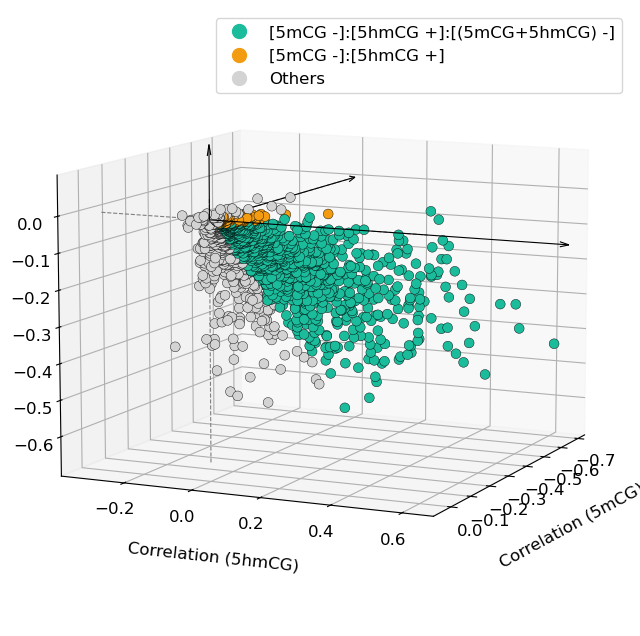

In [ ]:
def assign_fixed_colors(group_series, group1, group2):
    colors = []
    sizes = []
    for group in group_series:
        if group == group1:
            colors.append('#1abc9c')
            sizes.append(10)
        elif group == group2:
            colors.append('#f39c12')
            sizes.append(10)
        else:
            colors.append('lightgray')
            sizes.append(10)
    return np.array(colors)

colors = assign_fixed_colors(meta_data['group'], 
                             "[5mCG -]:[5hmCG +]:[(5mCG+5hmCG) -]", 
                             "[5mCG -]:[5hmCG +]")

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(x, y, z, c=colors, marker='o', s=50, alpha=1, edgecolors='k', linewidths=0.3)

ax.set_xlabel('Correlation (5mCG)', fontsize=12, labelpad=15)
ax.set_ylabel('Correlation (5hmCG)', fontsize=12, labelpad=15)
ax.set_zlabel('Correlation (5mCG+5hmCG)', fontsize=12, labelpad=15)

ax.quiver(0, 0, 0, -1, 0, 0, color='k', linewidth=0.8, length=0.7, arrow_length_ratio=0.045)
ax.quiver(0, 0, 0, 0, 1, 0, color='k', linewidth=0.8, length=1.0, arrow_length_ratio=0.025)
ax.quiver(0, 0, 0, 0, 0, 1, color='k', linewidth=0.8, length=0.2, arrow_length_ratio=0.15)

ax.plot([min(x), max(x)], [0, 0], [0, 0], color='gray', linestyle='--', linewidth=0.8)
ax.plot([0, 0], [min(y), max(y)], [0, 0], color='gray', linestyle='--', linewidth=0.8)
ax.plot([0, 0], [0, 0], [min(z), max(z)], color='gray', linestyle='--', linewidth=0.8)

ax.tick_params(axis='both', which='major', labelsize=12)

legend_elements = [
    mlines.Line2D([], [], color='#1abc9c', marker='o', linestyle='None', markersize=10, label="[5mCG -]:[5hmCG +]:[(5mCG+5hmCG) -]"),
    mlines.Line2D([], [], color='#f39c12', marker='o', linestyle='None', markersize=10, label="[5mCG -]:[5hmCG +]"),
    mlines.Line2D([], [], color='lightgray', marker='o', linestyle='None', markersize=10, label="Others")
]
ax.legend(handles=legend_elements, loc='upper right', prop={'size': 12})

# 这里可以调整视角
ax.view_init(elev=10, azim=25)

plt.savefig(f'{outdir}/23-3D_plot_genebody_CG_Cor_adjust20240927_latest2.pdf')

plt.show()
